# Transverse field ising model to primitives


In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import YGate, UnitaryGate
import numpy as np

SYGate = UnitaryGate(YGate().power(1/2), label=r"$\sqrt{Y}$")           # we create our own SYGate since it is not in the library
SYdgGate = UnitaryGate(SYGate.inverse(), label=r"$\sqrt{Y}^\dag$")    # We do the same for the inverse. (It is the unitary gate for the inverse of SYGate)

def generate_1d_tfim(num_qubits, num_trotter_steps, rx_angle, num_classical_bits = 0, trotter_barriers = False, layer_barriers = False):
    if num_classical_bits == 0:
        qc = QuantumCircuit(num_qubits)
    else:
        qc = QuantumCircuit(num_qubits, num_classical_bits)                     # creates quantum circuit (qc)

    for num_trotter_step in range(num_trotter_steps):           # for each trotter step in total number of steps
        add_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)             # we add one layer of the tfim 
        if trotter_barriers:
            qc.barrier()
        
    return  qc

def add_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers = False):        # we use layers to compress the gates of the circuits
    # Adding Rzz gates in even layers
    for i in range(0, qc.num_qubits-1, 2):
        qc.sdg([i, i+1])                                   # sdg stands for s dagger, we apply it on qubit i and i+1
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
    if layer_barriers:
        qc.barrier()
    
    # Adding Rzz gates in odd layers
    for i in range(1, qc.num_qubits-1, 2):
        qc.sdg([i, i+1])                                   # sdg stands for s dagger, we apply it on qubit i and i+1
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
    if layer_barriers:
        qc.barrier()
    
    qc.rx(rx_angle, list(range(qc.num_qubits))) 
    if layer_barriers:
        qc.barrier() 
        
        

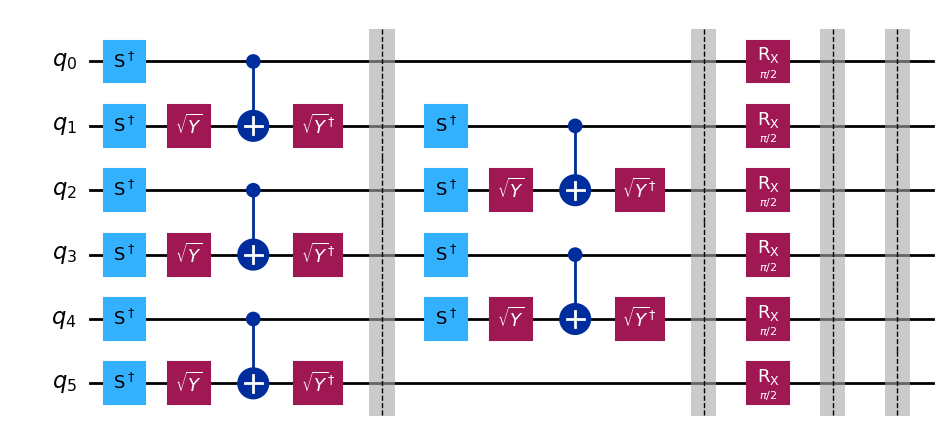

In [2]:
num_qubits = 6
num_trotter_steps = 1       #  trotter steps simulate time of a quantum system.    
rx_angle = 0.5 * np.pi      # rx angle to 0.5 * pi

qc = generate_1d_tfim(num_qubits, num_trotter_steps, rx_angle, trotter_barriers=True, layer_barriers=True)
qc.draw(output='mpl', fold=-1)           # fold = -1 allows it to be on one line



## demo: sampler

In [3]:
# now we code the circuit going backwards

def append_mirrored_1d_tfim(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barriers = False, layer_barriers = False):

    for num_trotter_step in range(num_trotter_steps):          
        add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)            
        if trotter_barriers:
            qc.barrier()
        
    # return  qc no need to return since we're adding directly

def add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers = False):        
    qc.rx(-rx_angle, list(range(qc.num_qubits)))         # we add all the single-qubit rx gates first, to invert we set angle to - sign
    if layer_barriers:
        qc.barrier() 
        
     # Adding Rzz gates in odd layers
    for i in range(1, qc.num_qubits-1, 2):
        qc.append(SYGate, [i+1])            # SY of SYdgGate is the SYGate
        qc.cx(i, i+1)                       # we then append the cnot gates which is it's own inverse
        qc.append(SYdgGate, [i+1])
        
        qc.s([i, i+1])            # inverted to an s gate
    
    if layer_barriers:
        qc.barrier()
       
    # Adding Rzz gates in even layers
    for i in range(0, qc.num_qubits-1, 2):
        qc.append(SYGate, [i+1])           
        qc.cx(i, i+1)                     
        qc.append(SYdgGate, [i+1])
        qc.s([i, i+1])       
    if layer_barriers:
        qc.barrier()
         

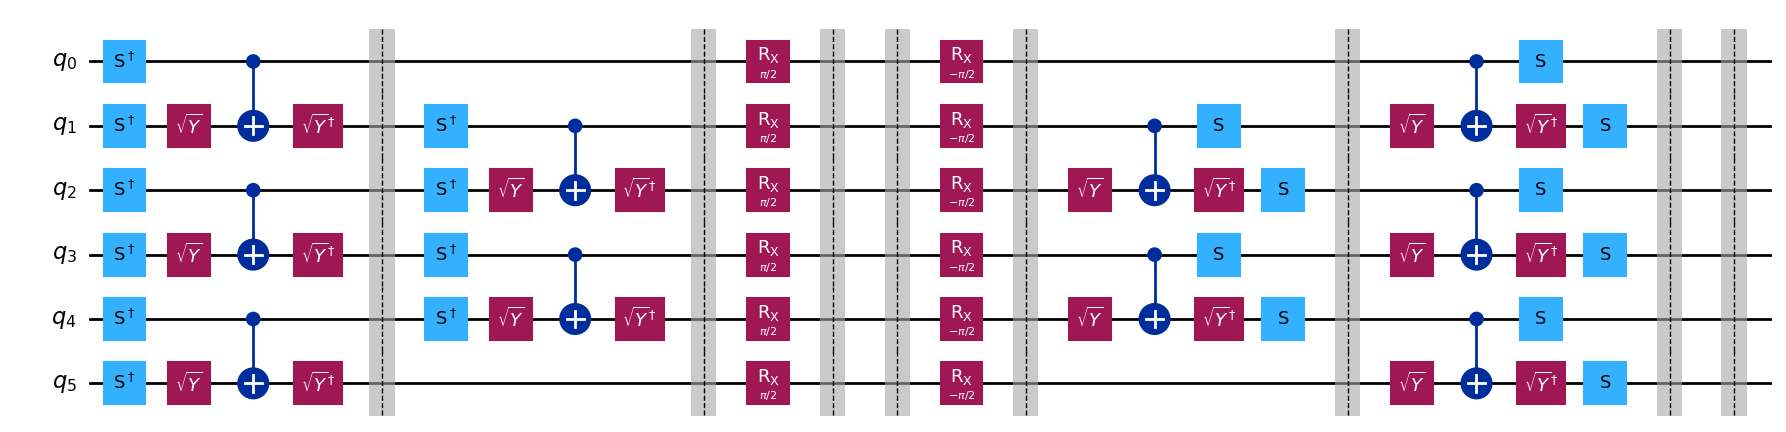

In [4]:
append_mirrored_1d_tfim(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barriers=True, layer_barriers=True)
qc.draw(output='mpl', fold=-1)

## 1: Mapping the problem to circuits and observables

In [5]:
# we want to increase number of trotter steps, and while inverting it at every step to check the survivability of the all 0-bit string

max_trotters = 10
num_qubits = 100
measured_qubits = [49,50]

qc_list =[]         # quantum circuit list
for trotter_step in range(max_trotters):
    qc = generate_1d_tfim(num_qubits, num_trotter_steps, rx_angle, num_classical_bits=len(measured_qubits), trotter_barriers=True, layer_barriers=True)
    append_mirrored_1d_tfim(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barriers=True, layer_barriers=True)    # then we mirror the circuit
    qc.measure(measured_qubits, list(range(len(measured_qubits))))
    qc_list.append(qc)
    

## 2: Optimizing

In [6]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = "ibm_brisbane"
service = QiskitRuntimeService()
backend = service.backend(backend_name)
print("Done getting backend")

qc_transpiled_list = transpile(qc_list, backend = backend, optimization_level=1)
 

Done getting backend


RequestsApiError: "HTTPSConnectionPool(host='api.quantum.ibm.com', port=443): Max retries exceeded with url: /runtime/backends/ibm_brisbane/properties (Caused by ResponseError('too many 500 error responses'))"

## 3: Execute on hardware

In [11]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"

job = sampler.run(qc_transpiled_list)
print(job.job_id())

cvdpcn2w5350008x0yd0


## 4: Post processing and plotting

In [7]:
job_id = "cvdpcn2w5350008x0yd0"
job = service.job(job_id)

survival_probablity_list = []                   # we want the survival probably of all 0 bit string
for trotter_step in range(max_trotters):
    try:
        data = job.result()[trotter_step].data          # get the data out of a particular trotter step
        survival_probablity_list.append(data.c.get_counts()['0' * len(measured_qubits)] / data.c.num_shots) # append the counts for bit string that has the all 0's 
    except:
        survival_probablity_list.append(0)
        
        
        

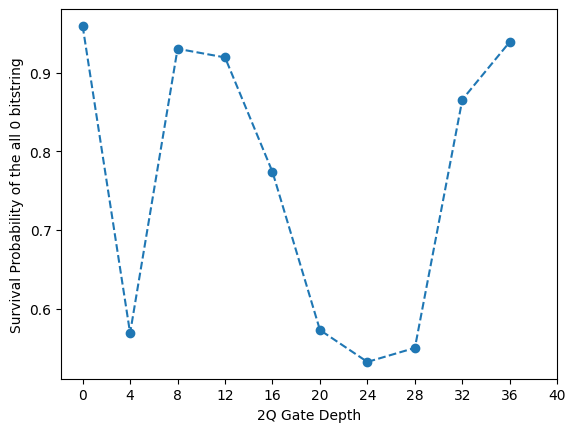

In [8]:
import matplotlib.pyplot as plt

plt.plot(list(range(0, 4 * max_trotters, 4)), survival_probablity_list, '--o')  # plots the x and y axis. X axis has trotter steps in intervals of 4
plt.xlabel('2Q Gate Depth')
plt.ylabel('Survival Probability of the all 0 bitstring')
plt.xticks(np.arange(0, 44, 4))
plt.show()


# Estimator to get expectation values

## 1: Mapping the problem

In [32]:
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp


rx_angle = Parameter("rx_angle")    # we say the rx_angle is a parameter    
trotter_steps = 2
qc = generate_1d_tfim(num_qubits, trotter_steps, rx_angle)       # we gonna measure the magnetization after sweeping over the rx_angle


middle_index = num_qubits // 2       
observable = SparsePauliOp("I" * middle_index + "Z" + "I" * (middle_index-1))    # we use Identities up until middle index, then we add the z operator and indentities for the rest





## 2: optimizing the circuit

In [64]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = 'ibm_brisbane'
service = QiskitRuntimeService()
backend = service.backend(backend_name)

qc_transpiled = transpile(qc, backend=backend, optimization_level=1)
observable = observable.apply_layout(qc_transpiled.layout)


RequestsApiError: "HTTPSConnectionPool(host='api.quantum.ibm.com', port=443): Max retries exceeded with url: /runtime/backends/ibm_brisbane/properties (Caused by ResponseError('too many 500 error responses'))"

## 3: Executing on quantum hardware

In [69]:
from qiskit_ibm_runtime import EstimatorV2, EstimatorOptions



# we define the range of rx_angles
min_rx_angle = 0
max_rx_angle = np.pi/2
num_rx_angle = 12       # looks at 12 of them in range
rx_angle_list = np.linspace(min_rx_angle, max_rx_angle, num_rx_angle)

options = EstimatorOptions()
options.resilience_level = 1 # resilience is 1 since it takes care of measurement errors
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"

estimator = EstimatorV2(backend=backend, options=options)

# job = estimator.run([(qc_transpiled, observable, rx_angle_list)])       # we pass in the transpiled qc, the 1 observable and the rx_angle_list that we sweep over
# print(job.job_id)         # after running once there is no need to run again


C:\Users\maxna\AppData\Local\Temp\ipykernel_6624\2508406408.py:16: DeprecationWarning: The 'backend' keyword arguments are deprecated as of qiskit-ibm-runtime 0.24.0 and will be removed no sooner than 3 months after the release date. Please use the 'mode' parameter instead.
  estimator = EstimatorV2(backend=backend, options=options)


# 4: Post processing and plotting

In [95]:
job_id = "cvb3ggta1h6g008ak57g"
job = service.job(job_id)

exp_val_list = job.result()[0].data.evs     # outputs the expectation values (evs)

plt.plot(rx_angle_list / np.pi, exp_val_list, '--o')
plt.xlabel(r'Rx angle ($\pi$)')
plt.ylabel(r'$\langle Z \rangle in the middle of the chain')
plt.ylim(-0.1, 1.1)

AttributeError: 'DataBin' object has no attribute 'evs'

0.28.0
